In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
data_root = Path(r"E:\MSc Works\IDS\output_cic_labelled_sessions")
csv_files = list(data_root.rglob("*.csv"))
sess_df = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)
sess_df = sess_df.drop_duplicates(subset=["Flow_ID", "Timestamp"], keep="last")
sess_df = sess_df.query("Found_Total>0")
sess_df = sess_df.dropna(subset="Output_File")
sess_df.shape

(10960, 24)

In [13]:
combined_df = pd.read_csv(r"E:\MSc Works\IDS\data\cicflow_combined.csv")
combined_df.columns = [col.lower() for col in combined_df.columns]
combined_df.shape

(41768, 85)

In [20]:
# combined_df.label.value_counts(normalize=True)
# sess_df.Label.value_counts(normalize=True)

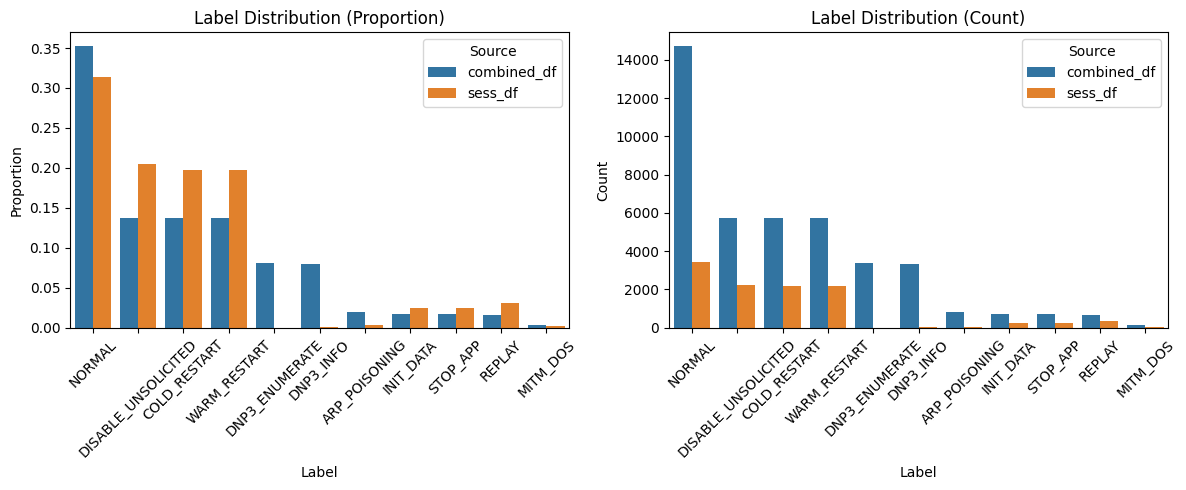

In [28]:
# Normalized value counts (proportions)
df1_counts = combined_df["label"].value_counts(normalize=True).rename("combined_df")
df2_counts = sess_df["Label"].value_counts(normalize=True).rename("sess_df")

# Raw counts
raw1 = combined_df["label"].value_counts().rename("combined_df")
raw2 = sess_df["Label"].value_counts().rename("sess_df")

# Combine for proportions
plot_df = (
    pd.concat([df1_counts, df2_counts], axis=1)
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "Label"})
)
plot_df_melt = plot_df.melt(id_vars="Label", var_name="Source", value_name="Proportion")

# Combine for counts
count_df = (
    pd.concat([raw1, raw2], axis=1)
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "Label"})
)
count_df_melt = count_df.melt(id_vars="Label", var_name="Source", value_name="Count")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=plot_df_melt, x="Label", y="Proportion", hue="Source", ax=axes[0])
axes[0].set_title("Label Distribution (Proportion)")
axes[0].set_ylabel("Proportion")
axes[0].set_xlabel("Label")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=count_df_melt, x="Label", y="Count", hue="Source", ax=axes[1])
axes[1].set_title("Label Distribution (Count)")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Label")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [29]:
imgs = list(Path(r"E:\MSc Works\IDS\output").rglob("*.png"))
len(imgs)

8654